# Bikeablity testing

Using this cell to read in some results for one place/scenario at a time, and investigate the different ways of computing bikeablity, along with a few sanity checks. I'm being lazy and reading the results from hard-coded file paths, so you'll need to adjust these.

## Setup

In [8]:
import pickle
import os
import glob
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt

## Sanity checks 

We load the first result of the "demand" growth order, as it is the most important result for sanity checking. This is because it should have selected the connection to make with the highest possible demand at that stage. We save as geopackages to use in QGIS or similar.

Saved: H:\Other\first_demand_full.gpkg
Saved: H:\Other\first_demand_abstract.gpkg


<Axes: >

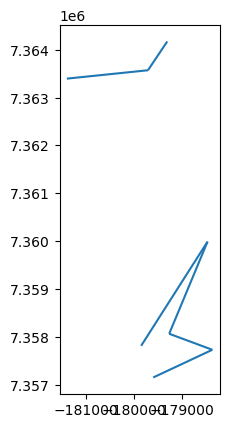

In [2]:
pickle_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario\newcastle_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"

with open(pickle_path, "rb") as f:
    data = pickle.load(f)

G_full = data["GTs"][1]
G_abs  = data["GT_abstracts"][1]

# Fix missing CRS in abstract graph
if "crs" not in G_abs.graph:
    G_abs.graph["crs"] = "EPSG:3857"

# Convert both graphs
nodes_full, edges_full = ox.graph_to_gdfs(G_full)
nodes_abs,  edges_abs  = ox.graph_to_gdfs(G_abs)

# Output paths
out_full = r"H:\Other\first_demand_full.gpkg"
out_abs  = r"H:\Other\first_demand_abstract.gpkg"


# Save full graph
nodes_full.to_file(out_full, layer="nodes", driver="GPKG")
edges_full.to_file(out_full, layer="edges", driver="GPKG")

# Save abstract graph
nodes_abs.to_file(out_abs, layer="nodes", driver="GPKG")
edges_abs.to_file(out_abs, layer="edges", driver="GPKG")

print("Saved:", out_full)
print("Saved:", out_abs)


edges_abs.plot()

- we can also get first iteration from the the random results to look at in QGIS or similar...

In [ ]:
input_folder = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario"

# Folder where you want to save the GeoPackages
output_folder = r"H:\Other"



pattern = os.path.join(input_folder, "newcastle_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")
files = sorted(glob.glob(pattern))
print(f"Found {len(files)} files")

for fpath in files:
    # Extract run number from filename
    fname = os.path.basename(fpath)
    run_id = fname.split("_run")[-1].split(".")[0]   # e.g. "00", "01", ...

    print(f"Processing run {run_id}...")

    # Load pickle
    with open(fpath, "rb") as f:
        data = pickle.load(f)

    # Extract graphs
    G_full = data["GTs"][1]            # or [0] if you want the first
    G_abs  = data["GT_abstracts"][1]   # or [0]

    # Fix missing CRS in abstract graph
    if "crs" not in G_abs.graph:
        G_abs.graph["crs"] = "EPSG:3857"

    # Convert to GeoDataFrames
    nodes_full, edges_full = ox.graph_to_gdfs(G_full)
    nodes_abs,  edges_abs  = ox.graph_to_gdfs(G_abs)

    # Output paths
    out_full = os.path.join(output_folder, f"random_run{run_id}_full.gpkg")
    out_abs  = os.path.join(output_folder, f"random_run{run_id}_abstract.gpkg")

    # Save full graph
    nodes_full.to_file(out_full, layer="nodes", driver="GPKG")
    edges_full.to_file(out_full, layer="edges", driver="GPKG")

    # Save abstract graph
    nodes_abs.to_file(out_abs, layer="nodes", driver="GPKG")
    edges_abs.to_file(out_abs, layer="edges", driver="GPKG")

    print(f"Saved run {run_id} to:")
    print("  ", out_full)
    print("  ", out_abs)

print("All runs processed.")


- we access the demand OD matrix which out trips are based on. the "total_flow" column is the number of trips

In [3]:
gpkg_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\newcastle\current_ltn_scenario\newcastle_current_ltn_scenario_greedy_demand_weighted.gpkg"
mydemand = gpd.read_file(gpkg_path)

mydemand.head()

,start_osmid,end_osmid,distance,sp_lts_route,sp_lts_distance,sp_true_distance,eucl_dist,ltn_origin,ltn_destination,start_norm,end_norm,osmid_pair,total_flow_x,total_flow_y,total_flow,geometry
0,826287045,1907450682,309.249812,None,445.726,445.726,309.249812,True,True,826287045,1907450682,None,15.702733,15.702733,15.702733,"LINESTRING (-1.62488 54.96771, -1.62136 54.96961)"
1,12091933082,4140896891,366.611193,None,1035.100,1035.100,366.611193,True,True,4140896891,12091933082,None,18.276293,18.276293,18.276293,"LINESTRING (-1.61558 54.97912, -1.61032 54.98041)"
2,2392633844,12091933082,406.684872,None,847.536,847.536,406.684872,True,True,2392633844,12091933082,None,16.762135,16.762135,16.762135,"LINESTRING (-1.61332 54.97571, -1.61558 54.97912)"
3,29013257,252100827,415.313673,None,1326.051,1326.051,415.313673,True,True,29013257,252100827,None,34.544636,34.544636,34.544636,"LINESTRING (-1.61430 55.00879, -1.61068 55.01189)"
4,776327170,345643357,481.877848,None,676.124,676.124,481.877848,True,True,345643357,776327170,None,29.505117,29.505117,29.505117,"LINESTRING (-1.58216 54.97811, -1.58948 54.97912)"


- map the demand from mydemand onto the abstract edges we have from above to check what sort of number of trips to expect.

In [ ]:
# Create a merge key in both tables
mydemand["edge_id"] = mydemand.apply(lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1)
edges_abs = edges_abs.reset_index()  # bring u, v, key into columns
edges_abs["edge_id"] = edges_abs.apply(lambda r: tuple(sorted((r.u, r.v))), axis=1)

# Merge total_flow onto edges_abs 
edges_abs = edges_abs.merge(mydemand[["edge_id", "total_flow"]], on="edge_id",how="left")

# edges_abs now contains a new column: total_flow
edges_abs.head()

# print how many trips we've got just on the first iteration
total_flow_sum = edges_abs["total_flow"].sum()
total_flow_sum

274.38774855271623

## Super simple bikeablity

The first way to try measureing bikeablity is to just measure each link's number of trips as it gets added. This doesn't consider that other routes might be available, or that some trips could already be done just fine. It does however work as a sanity check to see that the demand approach is 100% better than any random run. 

This first cell just does the first run from demand and random (you can skip this)

Loading reference demand data...
Processing DEMAND scenario...
  > Demand Flow: 274, Length: 9420
Found 100 random run files.
Processing Random Run 00...
Processing Random Run 01...
Processing Random Run 02...
Processing Random Run 03...
Processing Random Run 04...
Processing Random Run 05...
Processing Random Run 06...
Processing Random Run 07...
Processing Random Run 08...
Processing Random Run 09...
Processing Random Run 10...
Processing Random Run 11...
Processing Random Run 12...
Processing Random Run 13...
Processing Random Run 14...
Processing Random Run 15...
Processing Random Run 16...
Processing Random Run 17...
Processing Random Run 18...
Processing Random Run 19...
Processing Random Run 20...
Processing Random Run 21...
Processing Random Run 22...
Processing Random Run 23...
Processing Random Run 24...
Processing Random Run 25...
Processing Random Run 26...
Processing Random Run 27...
Processing Random Run 28...
Processing Random Run 29...
Processing Random Run 30...
Proces

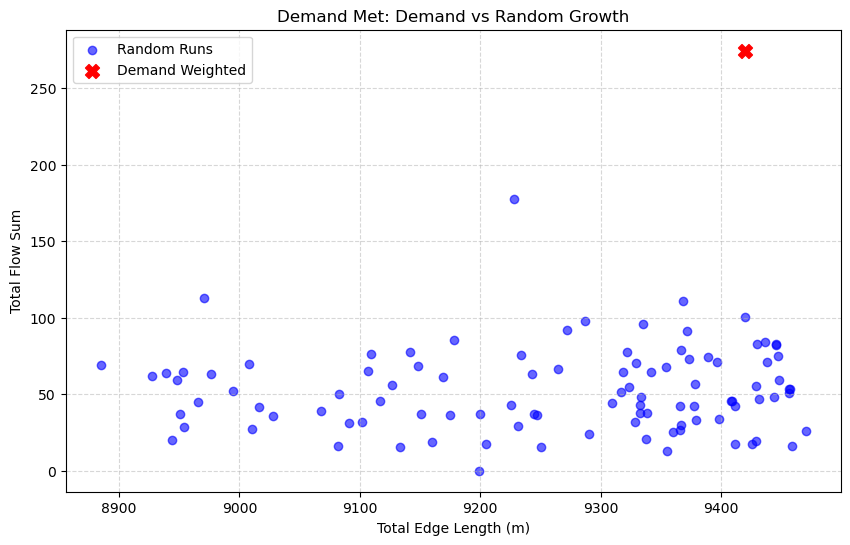

In [ ]:
# Path to the reference demand GPKG (contains 'total_flow' per edge)
ref_gpkg_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\newcastle\current_ltn_scenario\newcastle_current_ltn_scenario_greedy_demand_weighted.gpkg"
print("Loading reference demand data...")
mydemand = gpd.read_file(ref_gpkg_path)

# Create merge key 
mydemand["edge_id"] = mydemand.apply(lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1)
# Keep only what we need for merging to speed things up
reference_flow = mydemand[["edge_id", "total_flow"]]

# Output folder for GPKGs
output_folder = r"H:\Other"

# Lists to store plot data
plot_data = {
    "demand": {"flow": 0, "length": 0},
    "random": {"flow": [], "length": []}
}

def process_edges(edges_gdf, ref_df):
    """Helper to merge flow and calc stats"""
    edges_gdf = edges_gdf.copy()
    edges_gdf = edges_gdf.reset_index()
    edges_gdf["edge_id"] = edges_gdf.apply(lambda r: tuple(sorted((r.u, r.v))), axis=1)
    merged = edges_gdf.merge(ref_df, on="edge_id", how="left")
    total_len = merged.length.sum()
    total_flow = merged["total_flow"].sum()
    
    return total_len, total_flow


demand_pickle_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario\newcastle_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"
print(f"Processing DEMAND scenario...")
with open(demand_pickle_path, "rb") as f:
    data = pickle.load(f)
G_abs = data["GT_abstracts"][1]
if "crs" not in G_abs.graph: G_abs.graph["crs"] = "EPSG:3857"
nodes_abs, edges_abs = ox.graph_to_gdfs(G_abs)

# save for inspection 
out_abs = os.path.join(output_folder, "first_demand_abstract.gpkg")
nodes_abs.to_file(out_abs, layer="nodes", driver="GPKG")
edges_abs.to_file(out_abs, layer="edges", driver="GPKG")

# CALCULATE STATS
d_len, d_flow = process_edges(edges_abs, reference_flow)
plot_data["demand"]["length"] = d_len
plot_data["demand"]["flow"] = d_flow
print(f"  > Demand Flow: {d_flow:.0f}, Length: {d_len:.0f}")





input_folder = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario"
pattern = os.path.join(input_folder, "newcastle_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")
files = sorted(glob.glob(pattern))
print(f"Found {len(files)} random run files.")

for fpath in files:
    fname = os.path.basename(fpath)
    run_id = fname.split("_run")[-1].split(".")[0]
    print(f"Processing Random Run {run_id}...")
    with open(fpath, "rb") as f:
        data = pickle.load(f)
    G_abs = data["GT_abstracts"][1]
    if "crs" not in G_abs.graph: G_abs.graph["crs"] = "EPSG:3857"
    nodes_abs, edges_abs = ox.graph_to_gdfs(G_abs)
    
    # save for inspection
    out_abs = os.path.join(output_folder, f"random_run{run_id}_abstract.gpkg")
    nodes_abs.to_file(out_abs, layer="nodes", driver="GPKG")
    edges_abs.to_file(out_abs, layer="edges", driver="GPKG")
    
    # calcaulate stats
    r_len, r_flow = process_edges(edges_abs, reference_flow)
    plot_data["random"]["length"].append(r_len)
    plot_data["random"]["flow"].append(r_flow)

# plot
plt.figure(figsize=(10, 6))
plt.scatter(plot_data["random"]["length"], plot_data["random"]["flow"], 
            color='blue', alpha=0.6, label='Random Runs')
plt.scatter(plot_data["demand"]["length"], plot_data["demand"]["flow"], 
            color='red', s=100, marker='X', label='Demand Weighted', zorder=5)
plt.xlabel('Total Edge Length (m)')
plt.ylabel('Total Flow Sum')
plt.title('Demand Met: Demand vs Random Growth in iteration 1')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

- we can do the same but this time for the 2nd iteration just to check:

Loading reference demand data...
Processing DEMAND scenario...
  > Demand Flow: 312, Length: 14181
Found 100 random run files.
Processing Random Run 00...
Processing Random Run 01...
Processing Random Run 02...
Processing Random Run 03...
Processing Random Run 04...
Processing Random Run 05...
Processing Random Run 06...
Processing Random Run 07...
Processing Random Run 08...
Processing Random Run 09...
Processing Random Run 10...
Processing Random Run 11...
Processing Random Run 12...
Processing Random Run 13...
Processing Random Run 14...
Processing Random Run 15...
Processing Random Run 16...
Processing Random Run 17...
Processing Random Run 18...
Processing Random Run 19...
Processing Random Run 20...
Processing Random Run 21...
Processing Random Run 22...
Processing Random Run 23...
Processing Random Run 24...
Processing Random Run 25...
Processing Random Run 26...
Processing Random Run 27...
Processing Random Run 28...
Processing Random Run 29...
Processing Random Run 30...
Proce

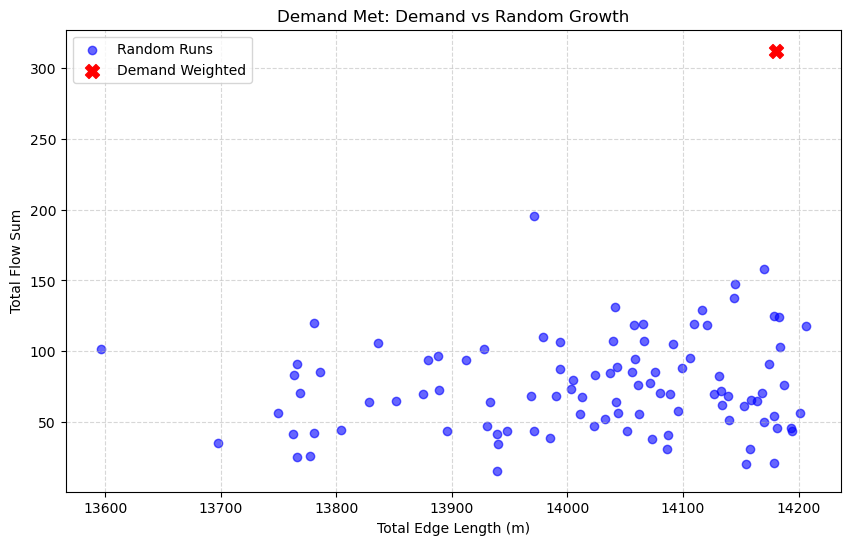

In [ ]:


# Path to the reference demand GPKG (contains 'total_flow' per edge)
ref_gpkg_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\newcastle\current_ltn_scenario\newcastle_current_ltn_scenario_greedy_demand_weighted.gpkg"
print("Loading reference demand data...")
mydemand = gpd.read_file(ref_gpkg_path)


mydemand["edge_id"] = mydemand.apply(
    lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1)

reference_flow = mydemand[["edge_id", "total_flow"]]
output_folder = r"H:\Other"

plot_data = {
    "demand": {"flow": 0, "length": 0},
    "random": {"flow": [], "length": []}}

def process_edges(edges_gdf, ref_df):
    """Helper to merge flow and calc stats"""
    edges_gdf = edges_gdf.copy()
    edges_gdf = edges_gdf.reset_index()
    edges_gdf["edge_id"] = edges_gdf.apply(
        lambda r: tuple(sorted((r.u, r.v))), axis=1)
    merged = edges_gdf.merge(ref_df, on="edge_id", how="left")
    total_len = merged.length.sum()
    total_flow = merged["total_flow"].sum()
    return total_len, total_flow


demand_pickle_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario\newcastle_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"
print(f"Processing DEMAND scenario...")
with open(demand_pickle_path, "rb") as f:
    data = pickle.load(f)
G_abs = data["GT_abstracts"][2]
if "crs" not in G_abs.graph: G_abs.graph["crs"] = "EPSG:3857"
nodes_abs, edges_abs = ox.graph_to_gdfs(G_abs)

# SAVE (As requested)
out_abs = os.path.join(output_folder, "first_demand_abstract.gpkg")
nodes_abs.to_file(out_abs, layer="nodes", driver="GPKG")
edges_abs.to_file(out_abs, layer="edges", driver="GPKG")

# CALCULATE STATS
d_len, d_flow = process_edges(edges_abs, reference_flow)
plot_data["demand"]["length"] = d_len
plot_data["demand"]["flow"] = d_flow
print(f"  > Demand Flow: {d_flow:.0f}, Length: {d_len:.0f}")

input_folder = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario"
pattern = os.path.join(input_folder, "newcastle_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")
files = sorted(glob.glob(pattern))

print(f"Found {len(files)} random run files.")
for fpath in files:
    fname = os.path.basename(fpath)
    run_id = fname.split("_run")[-1].split(".")[0]
    print(f"Processing Random Run {run_id}...")
    with open(fpath, "rb") as f:
        data = pickle.load(f)
    G_abs = data["GT_abstracts"][2]
    if "crs" not in G_abs.graph: G_abs.graph["crs"] = "EPSG:3857"
    nodes_abs, edges_abs = ox.graph_to_gdfs(G_abs)
    out_abs = os.path.join(output_folder, f"random_run{run_id}_abstract.gpkg")
    nodes_abs.to_file(out_abs, layer="nodes", driver="GPKG")
    edges_abs.to_file(out_abs, layer="edges", driver="GPKG")
    r_len, r_flow = process_edges(edges_abs, reference_flow)
    plot_data["random"]["length"].append(r_len)
    plot_data["random"]["flow"].append(r_flow)


plt.figure(figsize=(10, 6))
plt.scatter(plot_data["random"]["length"], plot_data["random"]["flow"], 
            color='blue', alpha=0.6, label='Random Runs')

plt.scatter(plot_data["demand"]["length"], plot_data["demand"]["flow"], 
            color='red', s=100, marker='X', label='Demand Weighted', zorder=5)

plt.xlabel('Total Edge Length (m)')
plt.ylabel('Total Flow Sum')
plt.title('Demand Met: Demand vs Random Growth on iteration 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

- since those look good, we can start to plot more runs:

Loading reference demand data...
Processing DEMAND scenario (First 10 steps)...
  Step 0: 203
  Step 1: 274
  Step 2: 312
  Step 3: 342
  Step 4: 407
  Step 5: 465
  Step 6: 554
  Step 7: 582
  Step 8: 638
  Step 9: 717
Processing 100 Random files (First 10 steps each)...


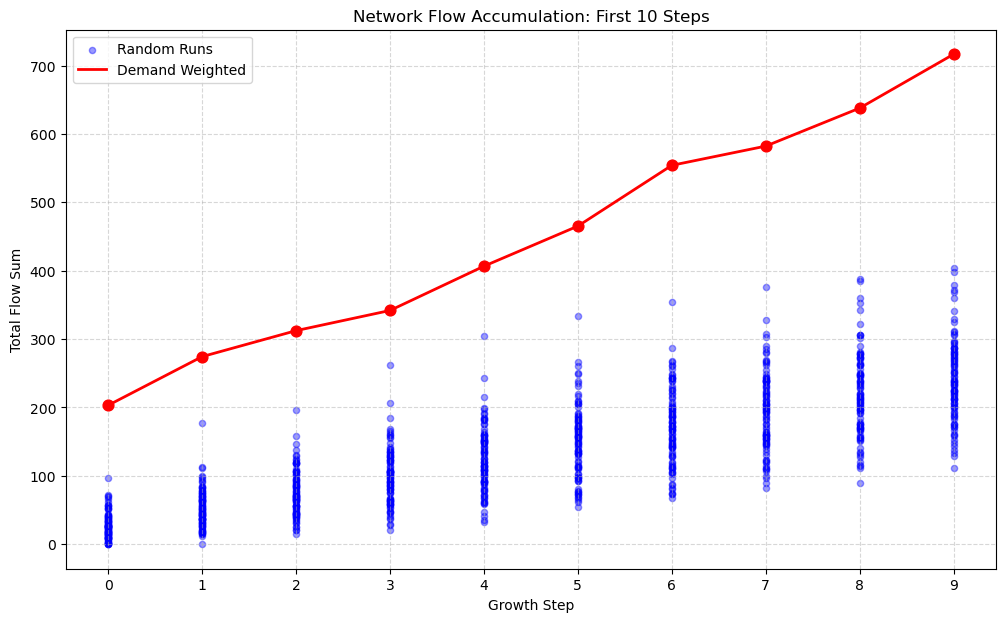

In [ ]:
ref_gpkg_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\newcastle\current_ltn_scenario\newcastle_current_ltn_scenario_greedy_demand_weighted.gpkg"
output_folder = r"H:\Other"
print("Loading reference demand data...")
mydemand = gpd.read_file(ref_gpkg_path)

# Create merge key on reference data (sorted tuple of node IDs)
mydemand["edge_id"] = mydemand.apply(
    lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1
)
reference_flow = mydemand[["edge_id", "total_flow"]]

# Number of steps to process
NUM_STEPS = 10

# Data storage
# demand: [flow_step0, flow_step1, ...]
# random: [[run0_step0, run1_step0...], [run0_step1...], ...]
plot_data = {"demand": [],
    "random": [[] for _ in range(NUM_STEPS)]}

def get_graph_stats(G, ref_df, save_path=None):
    """Helper: Convert graph to GDF, merge flow, return sum, optionally save"""
    if "crs" not in G.graph:
        G.graph["crs"] = "EPSG:3857"
    nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
    edges_gdf = edges_gdf.reset_index()
    
    # Create key
    edges_gdf["edge_id"] = edges_gdf.apply(
        lambda r: tuple(sorted((r.u, r.v))), axis=1)
    
    # Merge flow info
    merged = edges_gdf.merge(ref_df, on="edge_id", how="left")
    if save_path:
        merged.to_file(save_path, layer="edges", driver="GPKG")
    return merged["total_flow"].sum()

demand_pickle_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario\newcastle_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"
print(f"Processing DEMAND scenario (First {NUM_STEPS} steps)...")
with open(demand_pickle_path, "rb") as f:
    data = pickle.load(f)

# The list of abstract graphs over time
demand_graphs = data["GT_abstracts"]
for i in range(NUM_STEPS):
    if i >= len(demand_graphs): break
    out_path = os.path.join(output_folder, f"demand_step{i:02d}.gpkg")
    # Calculate and save
    flow_sum = get_graph_stats(demand_graphs[i], reference_flow, save_path=out_path)
    plot_data["demand"].append(flow_sum)
    print(f"  Step {i}: {flow_sum:.0f}")


input_folder = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario"
pattern = os.path.join(input_folder, "newcastle_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")
files = sorted(glob.glob(pattern))

print(f"Processing {len(files)} Random files (First {NUM_STEPS} steps each)...")
for fpath in files:
    # fname = os.path.basename(fpath) # unused for now
    with open(fpath, "rb") as f:
        data = pickle.load(f)
    random_graphs = data["GT_abstracts"]

    for i in range(NUM_STEPS):
        if i >= len(random_graphs): break
        # We don't save GPKGs here to avoid creating 500+ files, 
        # pass save_path=None just to get stats
        flow_sum = get_graph_stats(random_graphs[i], reference_flow, save_path=None)
        plot_data["random"][i].append(flow_sum)


plt.figure(figsize=(12, 7))
x_axis = range(len(plot_data["demand"]))

# Plot Random Runs (Blue Points needed for each step column)
for step_idx in x_axis:
    random_vals = plot_data["random"][step_idx]
    x_vals = [step_idx] * len(random_vals)
    if step_idx == 0:
        plt.scatter(x_vals, random_vals, color='blue', alpha=0.4, s=20, label='Random Runs')
    else:
        plt.scatter(x_vals, random_vals, color='blue', alpha=0.4, s=20)

plt.plot(x_axis, plot_data["demand"], color='red', linewidth=2, label='Demand Weighted', zorder=10)
plt.scatter(x_axis, plot_data["demand"], color='red', s=60, zorder=10)
plt.xlabel('Growth Step')
plt.ylabel('Trips')
plt.title(f'Demand met: First {NUM_STEPS} Steps')
plt.legend()
plt.xticks(x_axis)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

And now for all the runs: 

Loading reference demand data...
Processing DEMAND scenario (First 100 steps)...
  Step 0: 203
  Step 1: 274
  Step 2: 312
  Step 3: 342
  Step 4: 407
  Step 5: 465
  Step 6: 554
  Step 7: 582
  Step 8: 638
  Step 9: 717
  Step 10: 717
  Step 11: 741
  Step 12: 793
  Step 13: 841
  Step 14: 865
  Step 15: 926
  Step 16: 948
  Step 17: 981
  Step 18: 1024
  Step 19: 1066
  Step 20: 1105
  Step 21: 1124
  Step 22: 1163
  Step 23: 1218
  Step 24: 1252
  Step 25: 1283
  Step 26: 1299
  Step 27: 1309
  Step 28: 1337
  Step 29: 1367
  Step 30: 1397
  Step 31: 1411
  Step 32: 1425
  Step 33: 1464
  Step 34: 1498
  Step 35: 1524
  Step 36: 1536
  Step 37: 1562
  Step 38: 1585
  Step 39: 1607
  Step 40: 1629
  Step 41: 1639
  Step 42: 1660
  Step 43: 1680
  Step 44: 1698
  Step 45: 1717
  Step 46: 1735
  Step 47: 1743
  Step 48: 1752
  Step 49: 1776
  Step 50: 1793
  Step 51: 1809
  Step 52: 1825
  Step 53: 1833
  Step 54: 1847
  Step 55: 1860
  Step 56: 1874
  Step 57: 1880
  Step 58: 1894
  S

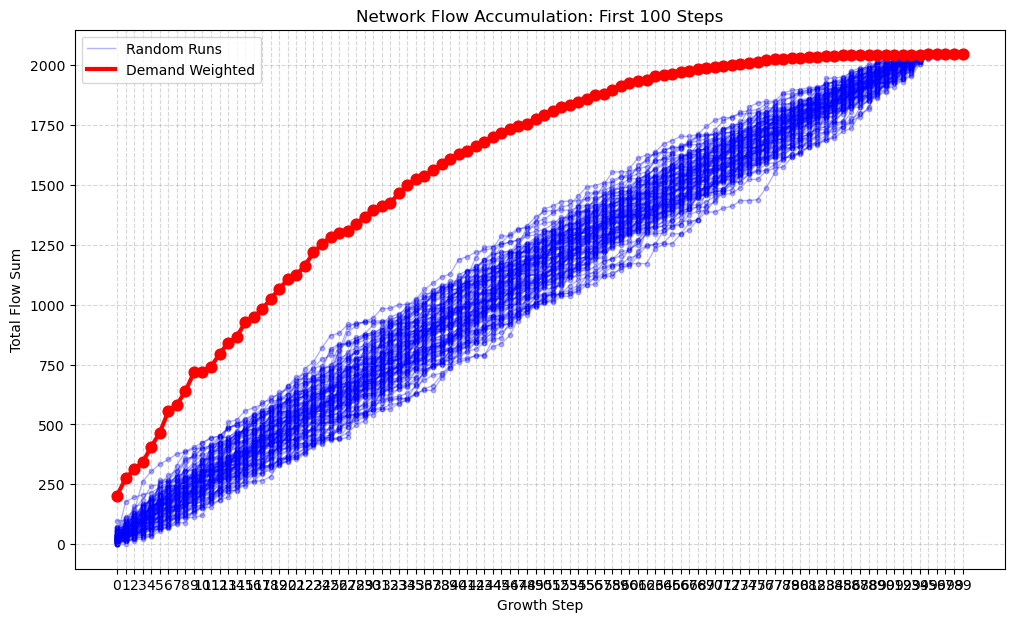

In [11]:
ref_gpkg_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\data\newcastle\current_ltn_scenario\newcastle_current_ltn_scenario_greedy_demand_weighted.gpkg"
output_folder = r"H:\Other"

print("Loading reference demand data...")
mydemand = gpd.read_file(ref_gpkg_path)

mydemand["edge_id"] = mydemand.apply(
    lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1)
reference_flow = mydemand[["edge_id", "total_flow"]]

NUM_STEPS = 100

# Data storage
plot_data = {
    "demand": [],        # [step0, step1, ...]
    "random_runs": []    # List of lists: [[run0_step0, run0_step1...], [run1_step0...]]
}

def get_graph_stats(G, ref_df, save_path=None):
    if "crs" not in G.graph:
        G.graph["crs"] = "EPSG:3857"     
    nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
    edges_gdf = edges_gdf.reset_index()
    edges_gdf["edge_id"] = edges_gdf.apply(
        lambda r: tuple(sorted((r.u, r.v))), axis=1
    )
    merged = edges_gdf.merge(ref_df, on="edge_id", how="left")
    if save_path:
        merged.to_file(save_path, layer="edges", driver="GPKG")
    return merged["total_flow"].sum()

demand_pickle_path = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario\newcastle_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"
print(f"Processing DEMAND scenario (First {NUM_STEPS} steps)...")
with open(demand_pickle_path, "rb") as f:
    data = pickle.load(f)
demand_graphs = data["GT_abstracts"]
for i in range(NUM_STEPS):
    if i >= len(demand_graphs): break
    out_path = os.path.join(output_folder, f"demand_step{i:02d}.gpkg")
    flow_sum = get_graph_stats(demand_graphs[i], reference_flow, save_path=out_path)
    plot_data["demand"].append(flow_sum)
    print(f"  Step {i}: {flow_sum:.0f}")


input_folder = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external\results\newcastle\current_ltn_scenario"
pattern = os.path.join(input_folder, "newcastle_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")
files = sorted(glob.glob(pattern))
print(f"Processing {len(files)} Random files (First {NUM_STEPS} steps each)...")

for fpath in files:
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        
    random_graphs = data["GT_abstracts"]
    current_run_flows = []

    for i in range(NUM_STEPS):
        if i >= len(random_graphs): break
        flow_sum = get_graph_stats(random_graphs[i], reference_flow, save_path=None)
        current_run_flows.append(flow_sum)
    
    plot_data["random_runs"].append(current_run_flows)


plt.figure(figsize=(12, 7))
x_axis = range(len(plot_data["demand"]))

# Plot Random Runs (Blue Lines)
# Loop through each run list individually
for idx, run_values in enumerate(plot_data["random_runs"]):
    # Handle case where a run might have fewer steps than NUM_STEPS
    run_x_axis = range(len(run_values))
    if idx == 0:
        plt.plot(run_x_axis, run_values, color='blue', alpha=0.3, linewidth=1, label='Random Runs')
    else:
        plt.plot(run_x_axis, run_values, color='blue', alpha=0.3, linewidth=1)
    
    # Optional: scatter points on top of lines
    plt.scatter(run_x_axis, run_values, color='blue', alpha=0.3, s=10)

# Plot Demand (Red Line and Points)
plt.plot(x_axis, plot_data["demand"], color='red', linewidth=3, label='Demand Weighted', zorder=10)
plt.scatter(x_axis, plot_data["demand"], color='red', s=60, zorder=10)
plt.xlabel('Growth Step')
plt.ylabel('Total Flow Sum')
plt.title(f'Network Flow Accumulation: First {NUM_STEPS} Steps')
plt.legend()
plt.xticks(x_axis)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Checking through manually

This bit of code will make plots to see actually what is happening "on the ground" for each run, to work out why random results might do so well when we measure bikeablity on a network bigger than just the abstract connections.